In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
import os
os.listdir(r"C:\Users\dipak\python\Sales_Data_Analysis\data")

['100 Sales Records.csv']

In [5]:
df = pd.read_csv(r"C:\Users\dipak\python\Sales_Data_Analysis\data\100 Sales Records.csv")

In [6]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [11]:
df.shape

(100, 14)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    str    
 1   Country         100 non-null    str    
 2   Item Type       100 non-null    str    
 3   Sales Channel   100 non-null    str    
 4   Order Priority  100 non-null    str    
 5   Order Date      100 non-null    str    
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    str    
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), str(7)
memory usage: 11.1 KB


In [13]:
df.isnull().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.606153e+08,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05
min,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.389225e+08,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05
50%,5.577086e+08,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05
75%,7.907551e+08,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05
max,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


In [16]:
df["Region"].unique()
df["Item Type"].unique()
df["Sales Channel"].unique()


<StringArray>
['Offline', 'Online']
Length: 2, dtype: str

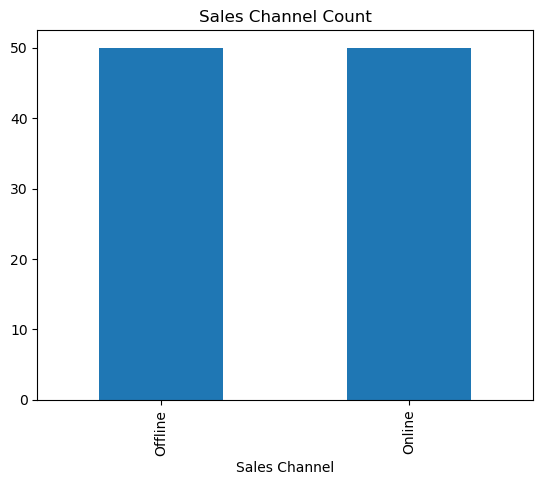

In [17]:
df["Sales Channel"].value_counts().plot(kind="bar")
plt.title("Sales Channel Count")
plt.show()

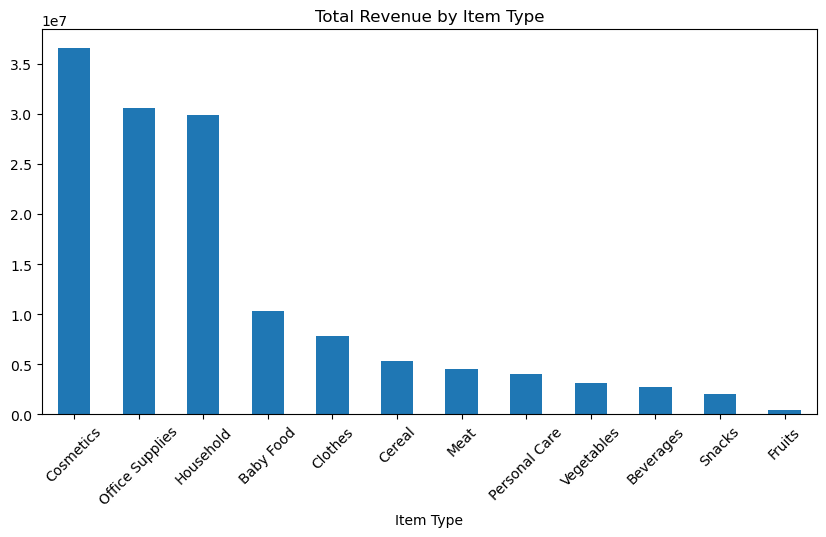

In [18]:
df.groupby("Item Type")["Total Revenue"].sum().sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Total Revenue by Item Type")
plt.xticks(rotation=45)
plt.show()

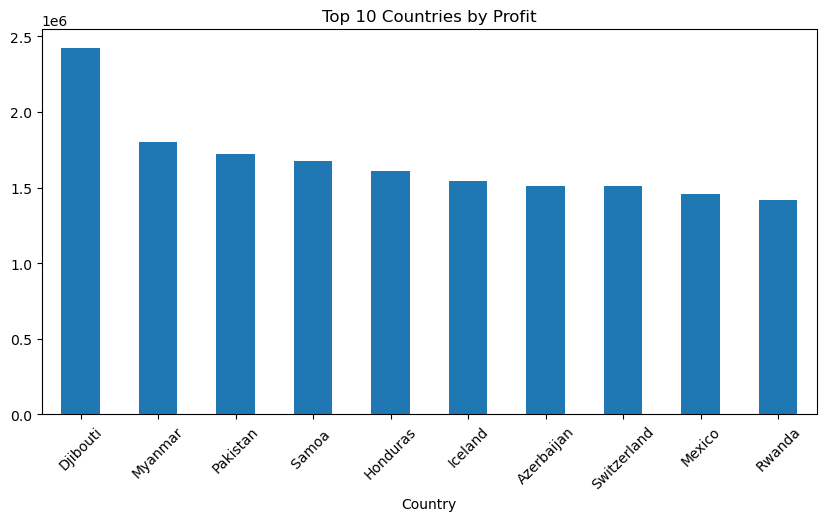

In [19]:
df.groupby("Country")["Total Profit"].sum().sort_values(ascending=False).head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Profit")
plt.xticks(rotation=45)
plt.show()

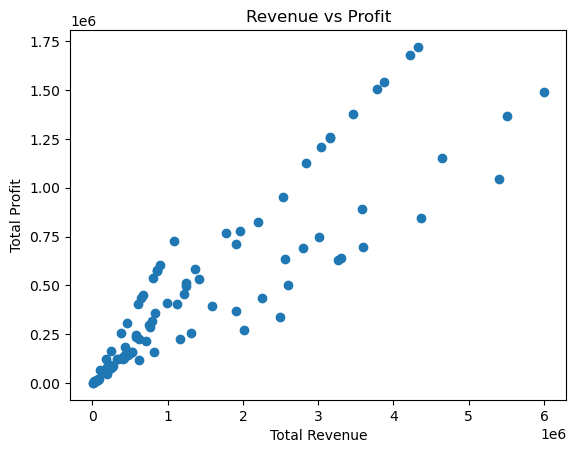

In [20]:
plt.scatter(df["Total Revenue"], df["Total Profit"])
plt.xlabel("Total Revenue")
plt.ylabel("Total Profit")
plt.title("Revenue vs Profit")
plt.show()

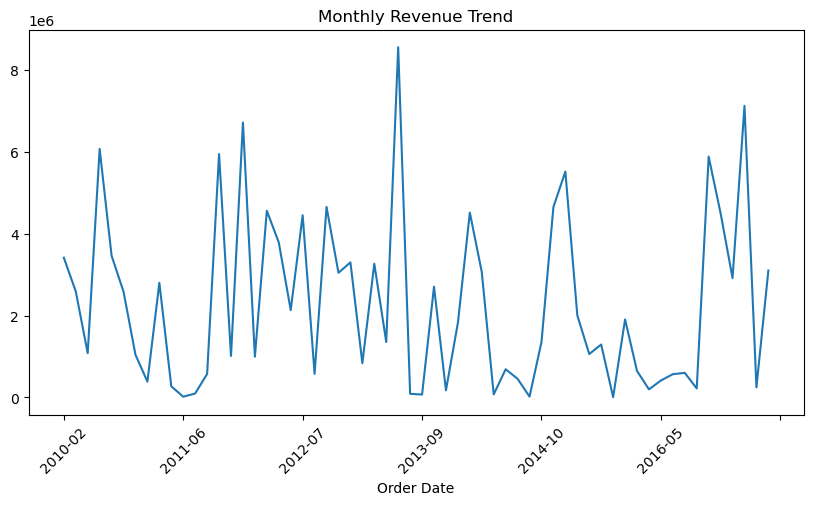

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Total Revenue"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

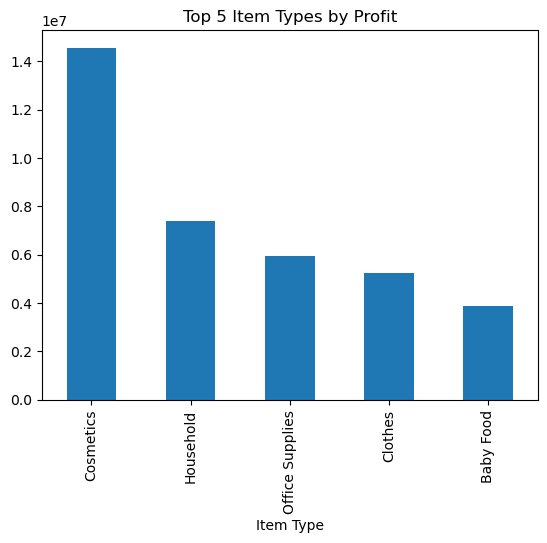

In [22]:
df.groupby("Item Type")["Total Profit"].sum().sort_values(ascending=False).head(5).plot(kind="bar")
plt.title("Top 5 Item Types by Profit")
plt.show()

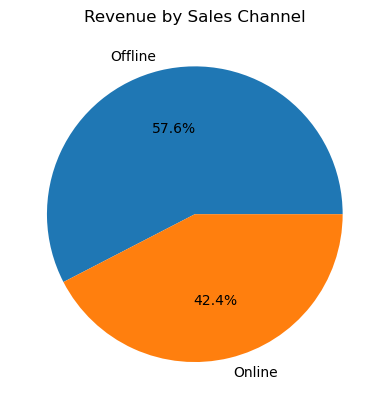

In [23]:
df.groupby("Sales Channel")["Total Revenue"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Sales Channel")
plt.ylabel("")
plt.show()

In [26]:
df["Total Profit"].mean()

np.float64(441681.98399999994)

In [27]:
df.loc[df["Total Revenue"].idxmax()]

Region            Central America and the Caribbean
Country                                    Honduras
Item Type                                 Household
Sales Channel                               Offline
Order Priority                                    H
Order Date                      2017-02-08 00:00:00
Order ID                                  522840487
Ship Date                                 2/13/2017
Units Sold                                     8974
Unit Price                                   668.27
Unit Cost                                    502.54
Total Revenue                            5997054.98
Total Cost                               4509793.96
Total Profit                             1487261.02
Name: 13, dtype: object